In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.colors import LogNorm

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-mvhhaevx because the default path (/homedir/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
from tractor import *
from tractor.galaxy import *
from tractor.sersic import *

In [48]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w'}
plt.rcParams.update(params)

psfsigma 2.431285391411014
NEA = 93.66 (6.43 arcsec^2)


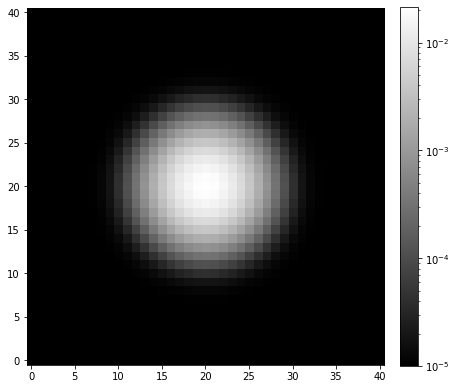

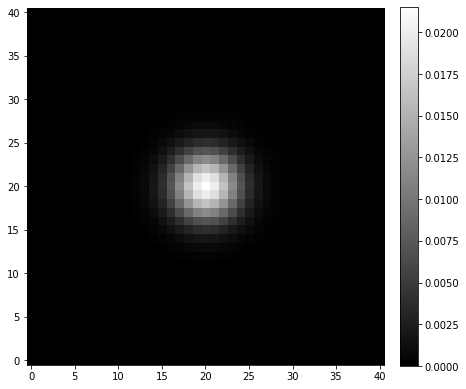

In [40]:
W, H = 41, 41
# psfsigma = 4.
psffwhm = 1.5 / 0.262
psfsigma = psffwhm / 2.3548
print('psfsigma', psfsigma)

tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
            psf=NCircularGaussianPSF([psfsigma], [1.]))

source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(1.3, 1, 45.))
tractor = Tractor([tim], [source])

mod = tractor.getModelImage(0)

nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))

plt.figure(figsize=(7, 7))
plt.imshow(mod + 1e-5, origin='lower', cmap='gray', norm=LogNorm())
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(mod, origin='lower', cmap='gray')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

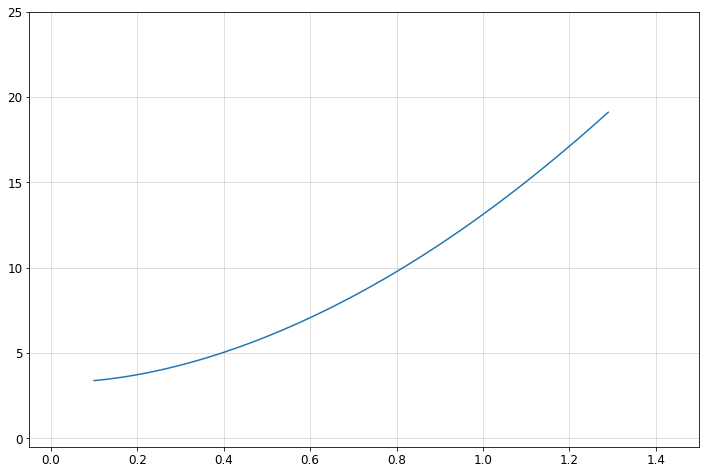

In [84]:
shape_r_list = np.arange(0.1, 1.3, 0.01)
nea_list = []

for shape_r in shape_r_list:

    psffwhm = 1.2 / 0.262
    psfsigma = psffwhm / 2.3548
    # print('psfsigma', psfsigma)

    tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                psf=NCircularGaussianPSF([psfsigma], [1.]))


    source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
    tractor = Tractor([tim], [source])

    mod = tractor.getModelImage(0)

    nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
    # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
    nea_list.append(nea)

shape_r_list = np.array(shape_r_list)
nea_list = np.array(nea_list)

plt.figure(figsize=(12, 8))
plt.plot(shape_r_list, nea_list*0.262**2)
plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

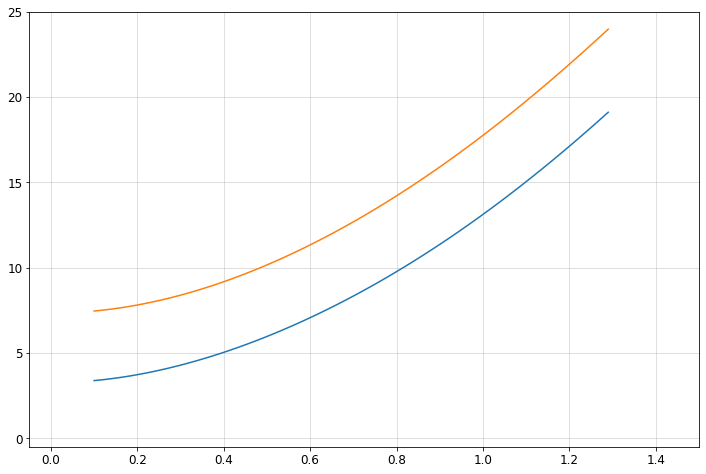

In [61]:
shape_r_list = np.arange(0.1, 1.3, 0.01)
nea_list = []

for shape_r in shape_r_list:

    psffwhm = 1.2 / 0.262
    psfsigma = psffwhm / 2.3548
    # print('psfsigma', psfsigma)

    tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                psf=NCircularGaussianPSF([psfsigma], [1.]))


    source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
    tractor = Tractor([tim], [source])

    mod = tractor.getModelImage(0)

    nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
    # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
    nea_list.append(nea)

shape_r_list1 = np.array(shape_r_list)
nea_list1 = np.array(nea_list)

###############################################################

shape_r_list = np.arange(0.1, 1.3, 0.01)
nea_list = []

for shape_r in shape_r_list:

    psffwhm = 1.8 / 0.262
    psfsigma = psffwhm / 2.3548
    # print('psfsigma', psfsigma)

    tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                psf=NCircularGaussianPSF([psfsigma], [1.]))


    source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
    tractor = Tractor([tim], [source])

    mod = tractor.getModelImage(0)

    nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
    # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
    nea_list.append(nea)

shape_r_list2 = np.array(shape_r_list)
nea_list2 = np.array(nea_list)

###############################################################

plt.figure(figsize=(12, 8))
plt.plot(shape_r_list1, nea_list1*0.262**2)
plt.plot(shape_r_list2, nea_list2*0.262**2)
plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

In [ ]:
PixelizedPSF

In [64]:
tt = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/calib/psfex/decam/CP/V4.9/CP20161123/c4d_161124_044849_ooi_g_ls9-psfex.fits'))

In [74]:
tt = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/calib/psfex/decam/CP/V4.8.2/CP20161107/c4d_161108_064120_ooi_g_ls9-psfex.fits'))

In [79]:
psfex = np.array(tt[9]['psf_mask'][0])

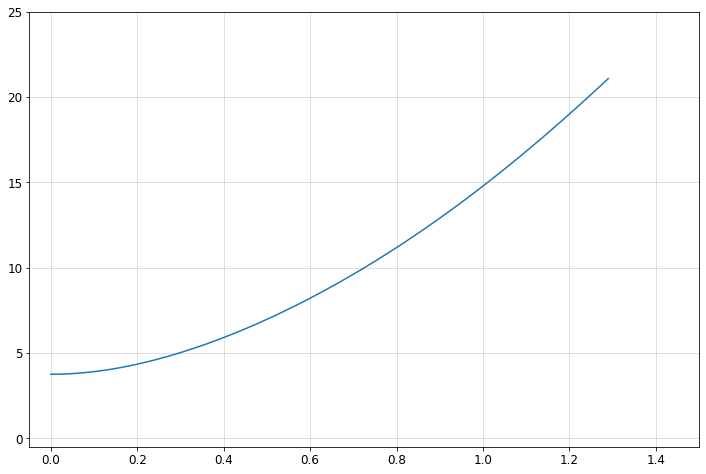

In [112]:
shape_r_list = np.arange(0., 1.3, 0.01)
nea_list = []

for shape_r in shape_r_list:

    psffwhm = 1.2 / 0.262
    psfsigma = psffwhm / 2.3548
    # print('psfsigma', psfsigma)

    tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                psf=PixelizedPSF(psfex))


    source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
    tractor = Tractor([tim], [source])

    mod = tractor.getModelImage(0)

    nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
    # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
    nea_list.append(nea)

shape_r_list = np.array(shape_r_list)
nea_list = np.array(nea_list)

plt.figure(figsize=(12, 8))
plt.plot(shape_r_list, nea_list*0.262**2)
plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

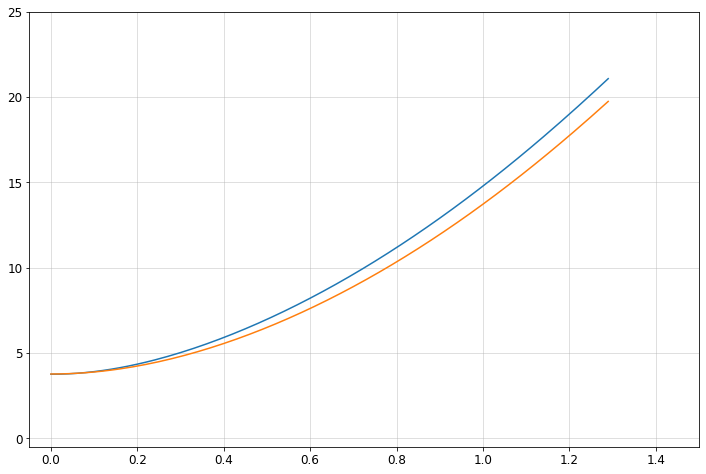

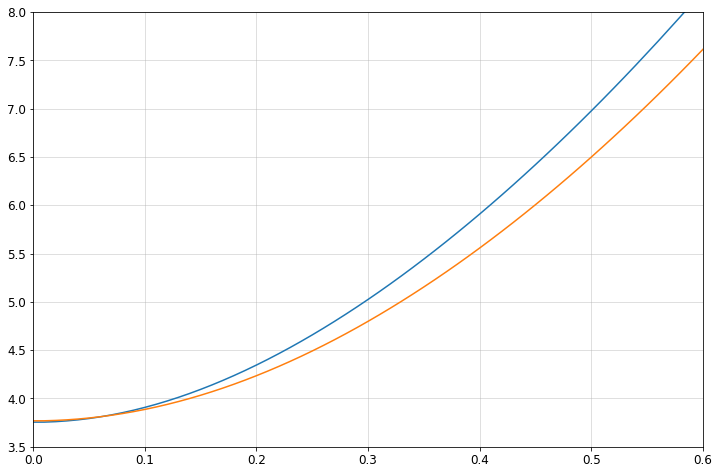

In [121]:
shape_r_list1 = np.arange(0., 1.3, 0.01)
nea_list1 = []

for shape_r in shape_r_list1:

    # psffwhm = 4.91
    # psffwhm = 4.78840446
    # psfsigma = psffwhm / 2.3548

    nea_psfex = np.sum(psfex)**2/np.sum(psfex**2) # in unit of number of pixels
    psfsigma = np.sqrt(nea_psfex/(4*np.pi))
    
    # print('psfsigma', psfsigma)

    tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                psf=NCircularGaussianPSF([psfsigma], [1.]))


    source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
    tractor = Tractor([tim], [source])

    mod = tractor.getModelImage(0)

    nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
    # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
    nea_list1.append(nea)

shape_r_list1 = np.array(shape_r_list1)
nea_list1 = np.array(nea_list1)

plt.figure(figsize=(12, 8))
plt.plot(shape_r_list, nea_list*0.262**2)
plt.plot(shape_r_list1, nea_list1*0.262**2)
plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 8))
plt.plot(shape_r_list, nea_list*0.262**2)
plt.plot(shape_r_list1, nea_list1*0.262**2)
plt.axis([0, 0.6, 3.5, 8])
plt.grid(alpha=0.5)
plt.show()